In [1]:
! wget -q https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip

In [ ]:
# Install Gradio if not already installed
!pip install gradio -q

In [2]:
# Unzip the file
!unzip "/content/Dogs vs Cats.zip"

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: train/train/dog.5499.jpg  
  inflating: train/train/dog.55.jpg  
  inflating: train/train/dog.550.jpg  
  inflating: train/train/dog.5500.jpg  
  inflating: train/train/dog.5501.jpg  
  inflating: train/train/dog.5502.jpg  
  inflating: train/train/dog.5503.jpg  
  inflating: train/train/dog.5504.jpg  
  inflating: train/train/dog.5505.jpg  
  inflating: train/train/dog.5506.jpg  
  inflating: train/train/dog.5507.jpg  
  inflating: train/train/dog.5508.jpg  
  inflating: train/train/dog.5509.jpg  
  inflating: train/train/dog.551.jpg  
  inflating: train/train/dog.5510.jpg  
  inflating: train/train/dog.5511.jpg  
  inflating: train/train/dog.5512.jpg  
  inflating: train/train/dog.5513.jpg  
  inflating: train/train/dog.5514.jpg  
  inflating: train/train/dog.5515.jpg  
  inflating: train/train/dog.5516.jpg  
  inflating: train/train/dog.5517.jpg  
  inflating: train/train/dog.5518.jpg  
  infl

Creating Greatintators

In [7]:
# Prefilled. Just copy and execute.
import os, math, re, random
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [9]:
import os, math, re, random
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

np.random.seed(42); tf.random.set_seed(42)

# Adjust paths based on the unzip output which indicates a 'train/train' structure.
# The 'unzip' command executed previously created a 'train' folder at the root level,
# and inside it another 'train' folder containing 'cat' and 'dog' images.
train_image_root = Path("train/train")

# IMPORTANT: The 'unzip' output did not explicitly show a 'test' directory structure.
# If your dataset also includes a 'test' folder (e.g., 'test/test' or 'test1'),
# you will need to adjust the 'test_image_root' path accordingly.
# For now, we will create an empty DataFrame for test to avoid immediate errors
# if the test data is not present or has a different structure.
test_image_root = Path("test") # Placeholder - verify actual path if using test data

IMG_HEIGHT, IMG_WIDTH = 180, 180
batch_size = 32
seed = 1337

# Function to build DataFrames from folders
def build_df_from_folder(folder: Path, labeled: bool=True):
    exts = ('*.jpg','*.jpeg','*.png','*.bmp')
    files = []
    for ex in exts:
        # Use rglob for recursive search of files within the specified folder
        files.extend(list(folder.rglob(ex)))

    if not files:
        # If no files are found, return an empty DataFrame to avoid FileNotFoundError
        # This allows the script to continue if a test set is genuinely missing or has a different path
        print(f"Warning: No images found under {folder}. Returning empty DataFrame.")
        return pd.DataFrame(columns=["filepath", "label"] if labeled else ["filepath"])

    rows = []
    for f in files:
        if labeled:
            name = f.name.lower()
            parent = f.parent.name.lower()
            if parent in {"cat","cats"}:
                label = "cat"
            elif parent in {"dog","dogs"}:
                label = "dog"
            else:
                # Fallback for filenames if parent folder is generic (e.g., 'train')
                if re.search(r'(^|[^a-z])cat([^a-z]|$)', name): label = "cat"
                elif re.search(r'(^|[^a-z])dog([^a-z]|$)', name): label = "dog"
                else:
                    continue # Skip if label cannot be determined
            rows.append({"filepath": str(f), "label": label})
        else:
            rows.append({"filepath": str(f)})
    return pd.DataFrame(rows)

# Create DataFrame for training data
df_train_full = build_df_from_folder(train_image_root, labeled=True)

# Create DataFrame for test data (may be empty if path is incorrect or data missing)
df_test_full  = build_df_from_folder(test_image_root,  labeled=False)

# Perform train-validation split if df_train_full is not empty
if not df_train_full.empty:
    df_tr, df_val = train_test_split(
        df_train_full, test_size=0.2, stratify=df_train_full["label"], random_state=seed
    )
    print(f"Total training images: {len(df_tr)}")
    print(f"Total validation images: {len(df_val)}")
else:
    print("No training data found. df_tr and df_val will be empty.")
    df_tr = pd.DataFrame(columns=["filepath", "label"])
    df_val = pd.DataFrame(columns=["filepath", "label"])


# Original code from the selected cell: count dog and cat labels from df_val
# This part will now execute after df_val has been defined.
dog_count = 0
cat_count = 0

if not df_val.empty:
    for label in df_val['label']:
        if label == "dog":
            dog_count += 1
        else: # Assuming only 'cat' if not 'dog' as per original problem (binary classification)
            cat_count += 1
    print("Dog count (validation set):", dog_count)
    print("Cat count (validation set):", cat_count)
else:
    print("Validation DataFrame (df_val) is empty, cannot count labels.")

Total training images: 20000
Total validation images: 5000
Dog count (validation set): 2500
Cat count (validation set): 2500


In [10]:
# Set fixed seed
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

In [11]:
# Paths change if needed
train_dir = "/content/train/train"
test_dir = "/content/test/test"

IMG_HEIGHT, IMG_WIDTH = 180, 180
batch_size = 128

In [12]:
# Build DataFrames from folders
def build_df_from_folder(folder: Path, labeled: bool=True):
    exts = ('*.jpg','*.jpeg','*.png','*.bmp')
    files = []
    for ex in exts:
        files.extend(glob(str(f'{folder}/**/*.jpg'), recursive=True))
    if not files:
        raise FileNotFoundError(f"No images found under {folder}")
    rows = []
    for f in files:
        if labeled:
            name = Path(f).name.lower()
            parent = Path(f).parent.name.lower()
            if parent in {"cat","cats"}:
                label = "cat"
            elif parent in {"dog","dogs"}:
                label = "dog"
            else:
                if re.search(r'(^|[^a-z])cat([^a-z]|$)', name): label = "cat"
                elif re.search(r'(^|[^a-z])dog([^a-z]|$)', name): label = "dog"
                else:
                    continue
            rows.append({"filepath": f, "label": label})
        else:
            rows.append({"filepath": f})
    return pd.DataFrame(rows)

df_train_full = build_df_from_folder(train_dir, labeled=True)
df_test_full  = build_df_from_folder(test_dir,  labeled=False)

In [13]:
print(len(df_test_full))
print(len(df_train_full))

50000
100000


In [14]:
# Train validation split
from sklearn.model_selection import train_test_split
df_tr, df_val = train_test_split(
    df_train_full, test_size=0.2, stratify=df_train_full["label"], random_state=SEED
)

In [15]:
# Train validation split
from sklearn.model_selection import train_test_split
df_tr, df_val = train_test_split(
    df_train_full, test_size=0.2, stratify=df_train_full["label"], random_state=SEED
)

# Generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.5,
    horizontal_flip=True,
)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)
val_flow = val_gen.flow_from_dataframe(
    df_val, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=False, validate_filenames=False
)
# Unlabeled test for inference only
test_flow = test_gen.flow_from_dataframe(
    df_test_full, x_col="filepath", y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None, batch_size=batch_size,
    shuffle=False, validate_filenames=False
)

print({"train": train_flow.samples, "val": val_flow.samples, "test": test_flow.samples,
       "class_indices": train_flow.class_indices})


Found 80000 non-validated image filenames belonging to 2 classes.
Found 20000 non-validated image filenames belonging to 2 classes.
Found 50000 non-validated image filenames.
{'train': 80000, 'val': 20000, 'test': 50000, 'class_indices': {'cat': 0, 'dog': 1}}


2.Inspect the data

In [16]:
dog_count = 0
cat_count = 0
for label in df_val['label']:
    if label  == "dog":
      dog_count += 1
    else:
      cat_count += 1
print(dog_count)
print(cat_count)

10000
10000


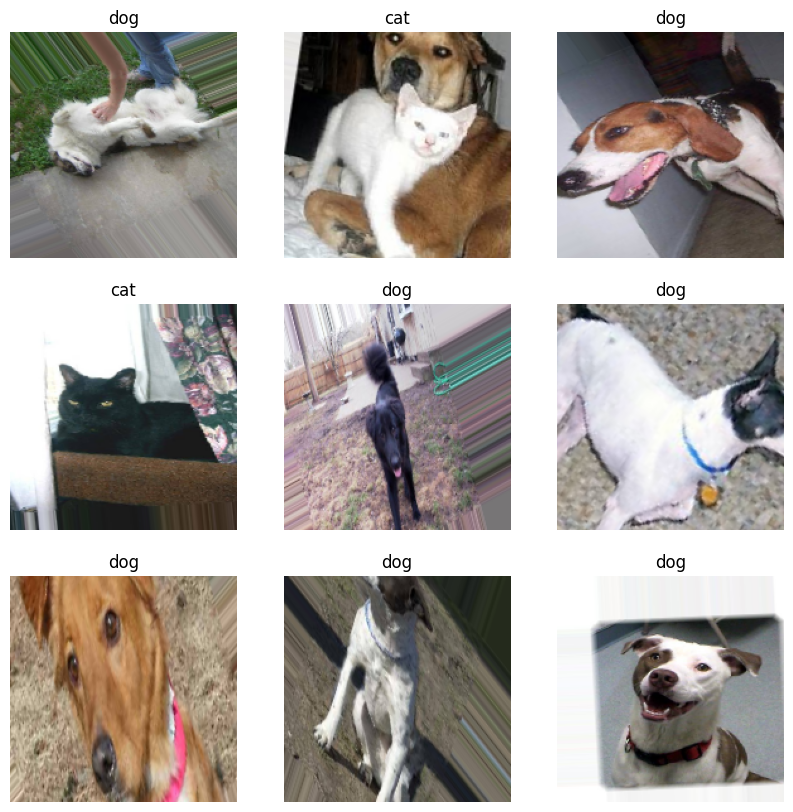

In [17]:
import matplotlib.pyplot as plt

#Get a batch of training images and labels
images, labels = next(train_flow)

#Get class names from the generator's class_indices
class_names = list(train_flow.class_indices.keys())

# Create a figure and a grid of subplots
plt.figure(figsize=(10, 10))
for i in range(9): # Display 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    #Convert binary label to class name
    label_index = int(labels[i])
    plt.title(class_names[label_index])
    plt.axis("off")
plt.show()


Defining the model's architecture

In [18]:
from keras import Sequential
my_model = Sequential()

In [19]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras import Sequential

my_model = Sequential()

# Convolutionat (input) layer; 180X180, 5X5, 32
my_model.add(Conv2D(32, (5, 5), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# MaxPooling (2X2)
my_model.add(MaxPooling2D((3, 3)))

#Convolutionat layer: 3X3, 64
my_model.add(Conv2D(32, (3, 3), activation='relu'))

# MaxPooling (2X2)
my_model.add(MaxPooling2D((2, 2)))

#Convolutionat layer: 3X3, 32
my_model.add(Conv2D(32, (3, 3), activation='relu'))

# MaxPooling (2X2)
my_model.add(MaxPooling2D((3, 3)))

# Flatten
my_model.add(Flatten())

# Dense Layer (using 126, units as an arbitrary common hoice, can be adjusted)
my_model.add(Dense(128, activation='relu'))

# Dropout (using a rate of 0.5 as a common choice, can be adjusted)
my_model.add(Dropout(0.5))

# Another Dense Layer (using 64 units)
my_model.add(Dense(64, activation='relu'))

# Output Layer (1 neuron for binary classification)
my_model.add(Dense(1, activation='sigmoid'))

# Print the model summary
my_model.summary()
my_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 176, 176, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 58, 58, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291,521 (1.11 MB)

 Trainable params: 291,521 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras import Sequential
import gradio as gr
import numpy as np
from PIL import Image

my_model = Sequential()

# Convolutionat (input) layer; 180X180, 5X5, 32
my_model.add(Conv2D(32, (5, 5), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# MaxPooling (2X2)
my_model.add(MaxPooling2D((3, 3)))

#Convolutionat layer: 3X3, 64
my_model.add(Conv2D(32, (5, 5), activation='relu'))

# MaxPooling (2X2)
my_model.add(MaxPooling2D((2, 2)))

#Convolutionat layer: 3X3, 32
my_model.add(Conv2D(32, (5, 5), activation='relu'))

# MaxPooling (2X2)
my_model.add(MaxPooling2D((3, 3)))

# Flatten
my_model.add(Flatten())

# Dense Layer (using 126, units as an arbitrary common hoice, can be adjusted)
my_model.add(Dense(128, activation='relu'))

# Dropout (using a rate of 0.5 as a common choice, can be adjusted)
my_model.add(Dropout(0.5))

# Another Dense Layer (using 64 units)
my_model.add(Dense(64, activation='relu'))

# Output Layer (1 neuron for binary classification)
my_model.add(Dense(1, activation='sigmoid'))

# Print the model summary
my_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 176, 176, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 58, 58, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 54, 54, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 27, 27, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 23, 23, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       200,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 262,849 (1.00 MB)

 Trainable params: 262,849 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

Training the model

In [23]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Recompile the model with the specified optimizer and learning rate
my_model.compile(
    optimizer=Adam(learning_rate=1e-2),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True

)


In [27]:
history = my_model.fit(
    train_flow,
    epochs=2, # Or a higher number with early stopping
    validation_data=val_flow,
    callbacks=[early_stopping] )

Epoch 1/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 2595s 4s/step - accuracy: 0.6347 - loss: 0.6328 - val_accuracy: 0.7313 - val_loss: 0.5388
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 2538s 4s/step - accuracy: 0.7158 - loss: 0.5554 - val_accuracy: 0.7725 - val_loss: 0.4746


In [32]:
my_model.save('my_model.keras')

### Interface Gradio pour l'Inférence

Cette cellule lance une interface Gradio qui vous permet de tester votre modèle. Vous pouvez coller une image ou en uploader une, et l'interface affichera la classe prédite (chien ou chat) ainsi que la confiance du modèle.

In [30]:
import gradio as gr
from PIL import Image
import numpy as np

# Prediction function for Gradio
def predict_image(image):
    if image is None:
        return "No image provided."

    # Preprocess the image to match the model's input requirements
    # Ensure IMG_WIDTH and IMG_HEIGHT are globally available or passed.
    # They are available from previous cells.
    image = Image.fromarray(image.astype('uint8'))
    image = image.resize((IMG_WIDTH, IMG_HEIGHT))
    image = np.asarray(image) / 255.0  # Rescale pixels to [0, 1]
    image = np.expand_dims(image, axis=0) # Add batch dimension

    # Make prediction
    # Ensure my_model is globally available or passed.
    # It is available from previous cells.
    prediction = my_model.predict(image)[0][0]

    # Determine class and confidence
    if prediction > 0.5:
        label = "Dog"
        confidence = prediction
    else:
        label = "Cat"
        confidence = 1 - prediction

    return f"Predicted: {label} with confidence {confidence:.2f}"

# Create and launch Gradio interface
if __name__ == '__main__':
    gr.Interface(
        fn=predict_image,
        inputs=gr.Image(type="numpy", label="Upload or Paste Image"),
        outputs="text",
        title="Dog vs Cat Classifier",
        description="Upload an image of a dog or a cat to get a prediction."
    ).launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://9c1d84c439504d672a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://9c1d84c439504d672a.gradio.live
